# Hand-In 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2a)

In [2]:
S1 = np.array([1, 1.09, 1.08, 1.34])
S2 = np.array([1,1.16,1.26,1.54])
S3 = np.array([1,1.22,1.07,1.03])
S4 = np.array([1,0.93,0.97,0.92])
S5 = np.array([1,1.11,1.56,1.52])
S6 = np.array([1,0.76,0.77,0.90])
S7 = np.array([1,0.92,0.84,1.01])
S8 = np.array([1,0.88,1.22,1.34])

stock_prices = np.vstack((S1, S2, S3, S4, S5, S6, S7, S8))

#Calculate sigma_RV
log_returns = np.log(stock_prices[:, 1:] / stock_prices[:, :-1])
sigma_RV = np.std(log_returns, ddof = 1)
print('sigma_RV = ', round(sigma_RV, 4), '+/-', round(sigma_RV/np.sqrt(2*(log_returns.size - 1)), 3))

#Calculate sigma_ML
r = 0.06
max_likelihood = -np.inf
sigma_vals = np.linspace(0.1, 0.2, 1000)
for sigma in sigma_vals:
    log_likelihood = -0.5 * np.sum(((log_returns - (r - 0.5 * sigma**2)) / sigma)**2) - log_returns.size * np.log(sigma) - 0.5 * log_returns.size * np.log(2 * np.pi)
    if log_likelihood > max_likelihood:
        max_likelihood = log_likelihood
        sigma_ML = sigma

#Calculate the standard error of sigma_ML
h = 10**(-5)
log_likelihood_plus = -0.5 * np.sum(((log_returns - (r - 0.5 * (sigma_ML + h)**2)) / (sigma_ML + h))**2) - log_returns.size * np.log(sigma_ML + h) - 0.5 * log_returns.size * np.log(2 * np.pi)
log_likelihood_minus = -0.5 * np.sum(((log_returns - (r - 0.5 * (sigma_ML - h)**2)) / (sigma_ML - h))**2) - log_returns.size * np.log(sigma_ML - h) - 0.5 * log_returns.size * np.log(2 * np.pi)
second_derivative = (log_likelihood_plus - 2 * max_likelihood + log_likelihood_minus) / h**2
sigma_ML_error = np.sqrt(- 1 / second_derivative)

print('sigma_ML = ', round(sigma_ML, 4), '+/-', round(sigma_ML_error, 3))


sigma_RV =  0.1519 +/- 0.022
sigma_ML =  0.1484 +/- 0.021


## 2b)

In [3]:
def binomial_puts(S0, T, strike, r, sigma, n, m, option_type = 'European'):
    dt = T/n                                            #time step
    u = np.exp(sigma * np.sqrt(dt))                     #up movement in stock price
    d = np.exp(-sigma * np.sqrt(dt))                    #down movement in stock price
    R = np.exp(r * dt)                                  #risk-free growth factor
    q = (R - d) / (u - d)                               #risk-neutral probability of up movement

    St_maturity = S0 * u**np.arange(0, n+1) * d**np.arange(n, -1, -1)   #stock prices at maturity
    price = np.maximum(0, strike - St_maturity)                         #possible option values at maturity

    for i in range(n, 1, -1):
        St = S0 * u**np.arange(0, i) * d**np.arange(i-1, -1, -1)                #stock prices at time step i - 1, where i is descending from n to 2
        exercise_value = np.maximum(0, strike - St)                             #exercise value at time step i - 1
        
        if option_type == 'European':                                           #european option cannot be exercised before maturity
            exercise_value = 0

        if option_type == 'American':                                           #american option can be exercised at any time
            exercise_value = np.maximum(0, strike - St)

        if option_type == 'Bermudan':                                           #bermudan option can only be exercised at the end of the year
            exercise_value = exercise_value * (i % m == 0)

        continuation_value = (q * price[1 : i + 1] + (1 - q) * price[0 : i]) / R        #expected value of holding the option, discounted back to time step i - 1
        price = np.maximum(continuation_value, exercise_value)                    #check if expected value of holding the option is less than the exercise value. If so, exercise the option
    
    return (q * price[1] + (1 - q) * price[0]) / R                                  #price at time 0, discounted back to present value

sigmas = [sigma_ML, 0.1500, sigma_RV]
m_year = 252                            #possible exercise dates per year
n_total = 3 * m_year                    #total time steps for binomial tree

for s in sigmas:
    price_european = binomial_puts(1, 3, 1.1, r, s, n_total, m_year, option_type = 'European')
    price_american = binomial_puts(1, 3, 1.1, r, s, n_total, m_year, option_type = 'American')
    price_bermudan = binomial_puts(1, 3, 1.1, r, s, n_total, m_year, option_type = 'Bermudan')
    print(f'For sigma = ', round(s, 4) ,': American put price =', round(price_american, 6), 'Bermudan put price = ', round(price_bermudan, 6), 'European put price = ', round(price_european, 6))

For sigma =  0.1484 : American put price = 0.108546 Bermudan put price =  0.091827 European put price =  0.062752
For sigma =  0.15 : American put price = 0.109175 Bermudan put price =  0.092719 European put price =  0.063706
For sigma =  0.1519 : American put price = 0.109938 Bermudan put price =  0.093794 European put price =  0.064869


## 2c)

In [4]:
def solve_lsm(S, strike, r, degree = 2):
    paths, steps = S.shape
    dt = 1
    cash_flows = np.maximum(strike - S[:, -1], 0)
    exercise_times = np.full(paths, steps - 1)
    
    for t in range(steps - 2, 0, -1):
        itm_mask = S[:, t] < strike #in the money mask
        
        if np.sum(itm_mask) > 0:
            X = S[itm_mask, t]
            Y = cash_flows[itm_mask] * np.exp(-r * (exercise_times[itm_mask] - t) * dt)
            A = np.vander(X, degree + 1, increasing = True)                                 #create matrix with 1, X, X^2 etc.
            coeffs = np.linalg.inv(A.T @ A) @ A.T @ Y                                       #least squares
            
            continuation_value = A @ coeffs
            intrinsic_value = strike - X

            exercise_mask = intrinsic_value > continuation_value
            exercise_indices = np.where(itm_mask)[0][exercise_mask]
            
            cash_flows[exercise_indices] = intrinsic_value[exercise_mask]
            exercise_times[exercise_indices] = t
            
    #take average of discounted cash flows for final price
    final_discounted_payoffs = cash_flows * np.exp(-r * exercise_times * dt)
    return np.mean(final_discounted_payoffs)

d_vals = [2, 3, 4, 5]
for d in d_vals:
    try:
        price = solve_lsm(stock_prices, strike = 1.1, r = 0.06, degree = d)
        print('Degree %s price: %s' % (d, round(price, 4)))
    except np.linalg.LinAlgError:
        print('Degree %s: Error, could not compute price.' % d)


Degree 2 price: 0.1144
Degree 3 price: 0.1154
Degree 4 price: 0.1243
Degree 5: Error, could not compute price.


## 2d)

Mean option price:  0.1068
Standard deviation:  0.0373


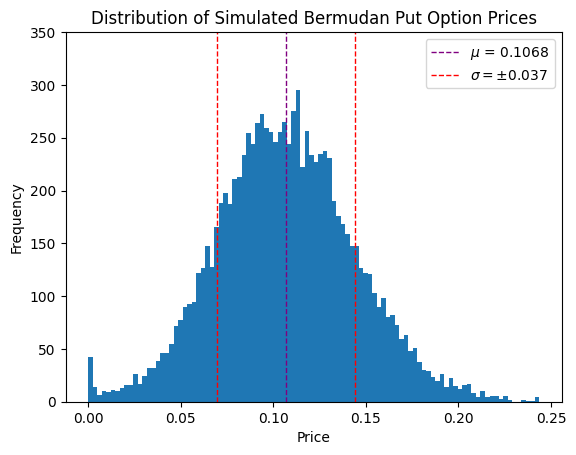

In [17]:
S0 = 1.0
K = 1.1
r = 0.06
sigma = 0.15
T = 3
steps = 3
paths_per_exp = 8
N_sim = 10000
dt = 1.0

def solve_lsm_8paths(S, strike, r_rate):
    paths, total_steps = S.shape
    P = np.zeros((paths, total_steps))          #cash flow matrix
    P[:, -1] = np.maximum(strike - S[:, -1], 0)

    for t in range(total_steps - 2, 0, -1):
        itm_mask = S[:, t] < strike
        if np.sum(itm_mask) < 3:                #we cant fit a 2nd degree polynomial with only 2 points or less
            continue
            
        X = S[itm_mask, t]
        Y = np.zeros(np.sum(itm_mask))
        A = np.vander(X, 3, increasing = True)

        #calculate discounted future cash flows for in the money paths
        for i, path_idx in enumerate(np.where(itm_mask)[0]):
            for future_t in range(t + 1, total_steps):
                if P[path_idx, future_t] > 0: #if there is a cash flow in the future, discount it back to time t and use it as Y value for regression 
                    Y[i] = P[path_idx, future_t] * np.exp(-r_rate * (future_t - t))
                    break
        
        coeffs = np.linalg.inv(A.T @ A) @ A.T @ Y
        continuation_value = A @ coeffs
        intrinsic_value = strike - X
        
        exercise_mask = intrinsic_value > continuation_value
        exercise_indices = np.where(itm_mask)[0][exercise_mask]
        
        P[exercise_indices, t] = intrinsic_value[exercise_mask]
        P[exercise_indices, t+1:] = 0                           #zero out future cash flows

    payoffs = np.zeros(paths)
    for i in range(paths):
        for t in range(1, total_steps):
            if P[i, t] > 0:
                payoffs[i] = P[i, t] * np.exp(-r_rate * t)      #discount cash flow back to present value
                break
    return np.mean(payoffs)

#Simulation loop
results = []
for _ in range(N_sim):
    S = np.zeros((paths_per_exp, steps + 1))
    S[:, 0] = S0
    for t in range(1, steps + 1):
        Z = np.random.standard_normal(paths_per_exp)
        S[:, t] = S[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    
    results.append(solve_lsm_8paths(S, K, r))
results = np.array(results)

#Plot
print('Mean option price: ', round(np.mean(results), 4))
print('Standard deviation: ', round(np.std(results, ddof=1), 4))
plt.hist(results, bins = 100)
plt.vlines(np.mean(results), 0, 1100, color='purple', linestyle='dashed', linewidth=1, label='$\mu$ = %s' % round(np.mean(results), 4))
plt.vlines(np.mean(results) + np.std(results, ddof=1), 0, 1100, color='red', linestyle='dashed', linewidth=1, label='$\sigma = \pm %s$' % round(np.std(results, ddof=1), 3))
plt.vlines(np.mean(results) - np.std(results, ddof=1), 0, 1100, color='red', linestyle='dashed', linewidth=1)
plt.ylim(0, 350)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Simulated Bermudan Put Option Prices')
plt.show()

## 2e)

In [28]:
N_sim = 10**7

#Regression coefficients from Longstaff and Schwartz
B1 = np.array([2.037512, -3.335443, 1.356457])
B2 = np.array([-1.06998, 2.983411, -1.813576])

#Simulate Paths
Z = np.random.standard_normal((N_sim, 3))
S = np.zeros((N_sim, 4))
S[:, 0] = S0
for t in range(1, 4):
    S[:, t] = S[:, t-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t-1])

def fixed_strategy(S, K, r, B1, B2):
    payoffs = np.zeros(N_sim)
    
    for i in range(N_sim):
        #t=1
        if S[i, 1] < K:
            intrinsic_value = K - S[i, 1]
            continuation_value = B1[0] + B1[1]*S[i, 1] + B1[2]*(S[i, 1]**2)
            if intrinsic_value > continuation_value:
                payoffs[i] = intrinsic_value * np.exp(-r * 1)
                continue
        
        #t=2
        if S[i, 2] < K:
            intrinsic_value = K - S[i, 2]
            continuation_value = B2[0] + B2[1]*S[i, 2] + B2[2]*(S[i, 2]**2)
            if intrinsic_value > continuation_value:
                payoffs[i] = intrinsic_value * np.exp(-r * 2)
                continue
                
        #t = 3
        payoffs[i] = max(K - S[i, 3], 0) * np.exp(-r * 3)
        
    return np.mean(payoffs)

expected_payoff = fixed_strategy(S, K, r, B1, B2)
print(f"Expected payoff from fixed strategy: {expected_payoff:.5f}")

Expected payoff from fixed strategy: 0.09002
